# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 2.0
---
### Contents  
> 1. *Generate Case Study Predictions*
> 2. *Geospatial Visualization* (in progress)
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 2025)  
It evaluates and compare the performance of three classification models:
- **XGBoost** (multi-class classification)
- **Random Forest**
- **K-Nearest Neighbors (KNN)**
---
### Inputs
`X.csv` Model data
`y.csv` Target data
`details.csv` details reguarding data

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map
from src.plot_utils import individual_plot_map
from src.plot_utils import interpolate_idw
from src.plot_utils import interpolate_idw2

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.lines as mlines  # For custom map legends

from datetime import timedelta

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

In [4]:
# Features and labels
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details.csv')


In [ ]:
details['Date'] = pd.to_datetime(details['Date']).dt.date

# Boolean mask for the date window
mask = (details['Date'] >= FIRST_DATE) & (details['Date'] <= LAST_DATE)

# MODEL (inside date range)
model_details = details.loc[mask]
model_X = X.loc[mask]
model_y = y.loc[mask]

# PAL (outside date range)
pal_details = details.loc[~mask]
pal_X = X.loc[~mask]
pal_y = y.loc[~mask]

### 1.1 Build Models

In [ ]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
Knn_parameters = model_parameters.loc['KNN'].dropna().to_dict()
optimal_learning_rate = XGB_parameters['learning_rate']

# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
Knn_parameters = convert_to_int(Knn_parameters)

XGB_parameters['learning_rate'] = optimal_learning_rate
#optimal_learning_rate = XGB_parameters['learning_rate']

In [11]:
# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
Knn_parameters = convert_to_int(Knn_parameters)


In [13]:
display(RF_parameters)
display(XGB_parameters)
display(Knn_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 2,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'n_estimators': 200,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': 0.4}

{'n_neighbors': 2, 'weights': 'distance'}

In [ ]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_knn = KNeighborsClassifier(**Knn_parameters)

### 1.2 Train Models

In [15]:
X_train, X_test, y_train, y_test = train_test_split(model_X, model_y, test_size=0.2, random_state=14)

#### (Optional) Downsize Majority Class for processing power

In [16]:
# Combine X_train and y_train
train = X_train.copy()
train['Target'] = y_train

# Split by class
class0 = train[train['Target'] == 0]   # Low
class1 = train[train['Target'] == 1]   # Moderate
class2 = train[train['Target'] == 2]   # High (no downsampling)

# --- Choose your downsample sizes ---
n_class0 = 50000   # or whatever number you want
#n_class1 = 5000 # example size — adjust as needed  
# ------------------------------------

# Downsample 0 and 1
class0_down = class0.sample(n=n_class0, random_state=14)
#class1_down = class1.sample(n=n_class1, random_state=14)

# Combine
train_balanced = pd.concat([class0_down,class1, class2])

# Shuffle
train_balanced = (
    train_balanced.sample(frac=1, random_state=14)
    .reset_index(drop=True)
)

# Split back into X and y
X_train = train_balanced.drop(columns='Target')
y_train = train_balanced['Target']




In [17]:
optimum_xgb_model.fit(X_train, y_train)
optimum_rf.fit(X_train, y_train)
optimum_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2, weights='distance')

In [18]:
rf_importances = optimum_rf.feature_importances_
for name, importance in zip(X.columns, rf_importances):
    print(f"{name}: {importance:.4f}")

ETo (in) x 2-Year Avg Fires: 0.1377
Avg Air Temp (F) x Avg Air Temp (F) 7 Day Avg: 0.1406
ETo (in) x Season: 0.0962
ETo (in) x Avg Vap Pres (mBars): 0.1024
Avg Vap Pres (mBars) x Avg Air Temp (F): 0.1096
ETo (in) x Avg Air Temp (F): 0.1153
Avg Wind Speed (mph) x 2-Year Avg Fires: 0.0916
Avg Vap Pres (mBars) x Season: 0.1241
Sample_Elevation x 2-Year Avg Fires: 0.0826


In [19]:
xgb_importances = optimum_xgb_model.feature_importances_
for name, importance in zip(X.columns, xgb_importances):
    print(f"{name}: {importance:.4f}")

ETo (in) x 2-Year Avg Fires: 0.2346
Avg Air Temp (F) x Avg Air Temp (F) 7 Day Avg: 0.0880
ETo (in) x Season: 0.1376
ETo (in) x Avg Vap Pres (mBars): 0.0849
Avg Vap Pres (mBars) x Avg Air Temp (F): 0.0860
ETo (in) x Avg Air Temp (F): 0.1117
Avg Wind Speed (mph) x 2-Year Avg Fires: 0.0827
Avg Vap Pres (mBars) x Season: 0.1094
Sample_Elevation x 2-Year Avg Fires: 0.0652


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [21]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [ ]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  0.973
Precision: 0.979
Recall:    0.973
F1 Score:  0.975
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     87107
           1       0.39      0.42      0.41       506
           2       0.31      0.51      0.39      1148

    accuracy                           0.97     88761
   macro avg       0.56      0.64      0.59     88761
weighted avg       0.98      0.97      0.98     88761



Evaluation for Random Forest
Accuracy:  0.940
Precision: 0.979
Recall:    0.940
F1 Score:  0.957
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     87107
           1       0.19      0.58      0.29       506
           2       0.18      0.69      0.28      1148

    accuracy                           0.94     88761
   macro avg       0.46      0.74      0.51     88761
weighted avg       0.98      0.94      

In [ ]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

In [ ]:
evaluate_model(optimum_knn, X_test, y_test, "KNN")

### 1.3 Generate Predictions

In [23]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_knn_predictions = pd.DataFrame(optimum_knn.predict(pal_X))

# Apply reverse mapping to all prediction sets
pal_xgb_predictions[0] = pal_xgb_predictions[0].replace(label_map)
pal_rf_predictions[0] = pal_rf_predictions[0].replace(label_map)
pal_knn_predictions[0] = pal_knn_predictions[0].replace(label_map)

In [24]:
pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction KNN'] = pal_knn_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values

C:\Users\dusti\AppData\Local\Temp\ipykernel_17212\1898117021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_17212\1898117021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction KNN'] = pal_knn_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_17212\1898117021.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [25]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_specific_date_end = pd.to_datetime('2025-01-12').date()

pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

C:\Users\dusti\AppData\Local\Temp\ipykernel_17212\1497241495.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date


In [26]:
pal_predictions = pal_details[pal_details['Date'] == pal_specific_date]

In [27]:
forward = timedelta(days = 1)
pal_specific_date + forward

datetime.date(2025, 1, 8)

In [28]:
pal_predictions

,Sample_ID,Date,Region_ID,Sample_Longitude,Sample_Latitude,Region_Name,Stn_Id,Stn_Name,County,geometry_x,Stn Name,CIMIS Region,fire_count,total_fire_damage,_merge,Prediction XGB,Prediction KNN,Prediction RF
444839,5,2025-01-07,6,-115.232017,32.778837,Inland Deserts Region,87,Meloland,Imperial,POINT (447107.37076055177 -570275.4707888691),Meloland,Imperial/Coachella Valley,0,0.0,both,0,0,0
444840,171,2025-01-07,1,-121.232017,41.778837,Northern Region,91,Tulelake FS,Siskiyou,POINT (-102588.28849189347 418574.45107100904),Tulelake FS,Northeast Plateau,0,0.0,both,0,0,0
444841,122,2025-01-07,2,-119.732017,38.778837,North Central Region,246,Markleeville,Alpine,POINT (23257.248421090713 84789.07029244956),Markleeville,Eastern Sierra Basin & Range,0,0.0,both,0,0,0
444842,125,2025-01-07,2,-122.732017,39.278837,North Central Region,250,Williams,Colusa,POINT (-235463.41957832582 143721.63184328936),Williams,Sacramento Valley,0,0.0,both,0,0,0
444843,23,2025-01-07,5,-118.232017,34.278837,South Coast Region,216,Arleta,Los Angeles,POINT (162748.55781856657 -413715.54818751756),Arleta,Los Angeles Basin,0,0.0,both,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445007,103,2025-01-07,4,-120.232017,37.778837,Central Region,206,Denair II,Stanislaus,POINT (-20407.69656944255 -26381.160519274883),Denair II,San Joaquin Valley,0,0.0,both,0,0,0
445008,132,2025-01-07,1,-123.232017,39.778837,Northern Region,106,Sanel Valley,Mendocino,POINT (-276647.750370695 200603.98285926413),Sanel Valley,North Coast Valleys,0,0.0,both,0,0,0
445009,69,2025-01-07,4,-121.232017,36.278837,Central Region,114,Arroyo Seco,Monterey,POINT (-110528.13221078689 -192414.73697720794),Arroyo Seco,Monterey Bay,0,0.0,both,0,0,0
445010,86,2025-01-07,6,-118.232017,36.778837,Inland Deserts Region,183,Owens Lake North,Inyo,POINT (157571.03816830233 -136095.8703730614),Owens Lake North,Bishop,0,0.0,both,0,0,0


In [29]:
# Create geometry from lat/lon
pal_geometry = [Point(xy) for xy in zip(pal_predictions['Sample_Longitude'], pal_predictions['Sample_Latitude'])]

# Convert to GeoDataFrames
pal_gdf = gpd.GeoDataFrame(pal_predictions, geometry=pal_geometry, crs="EPSG:4326")

In [30]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)
pal_details.to_csv('../data/processed/pal_details.csv', index=False)

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025) and the Dixie Fire (July 2021).

In [31]:
pal_gdf.rename(columns={'Sample_Longitude': 'Longitude'}, inplace=True)
pal_gdf.rename(columns={'Sample_Latitude': 'Latitude'}, inplace=True)

### 2.1 Palisades + Eaton Fire Predictions

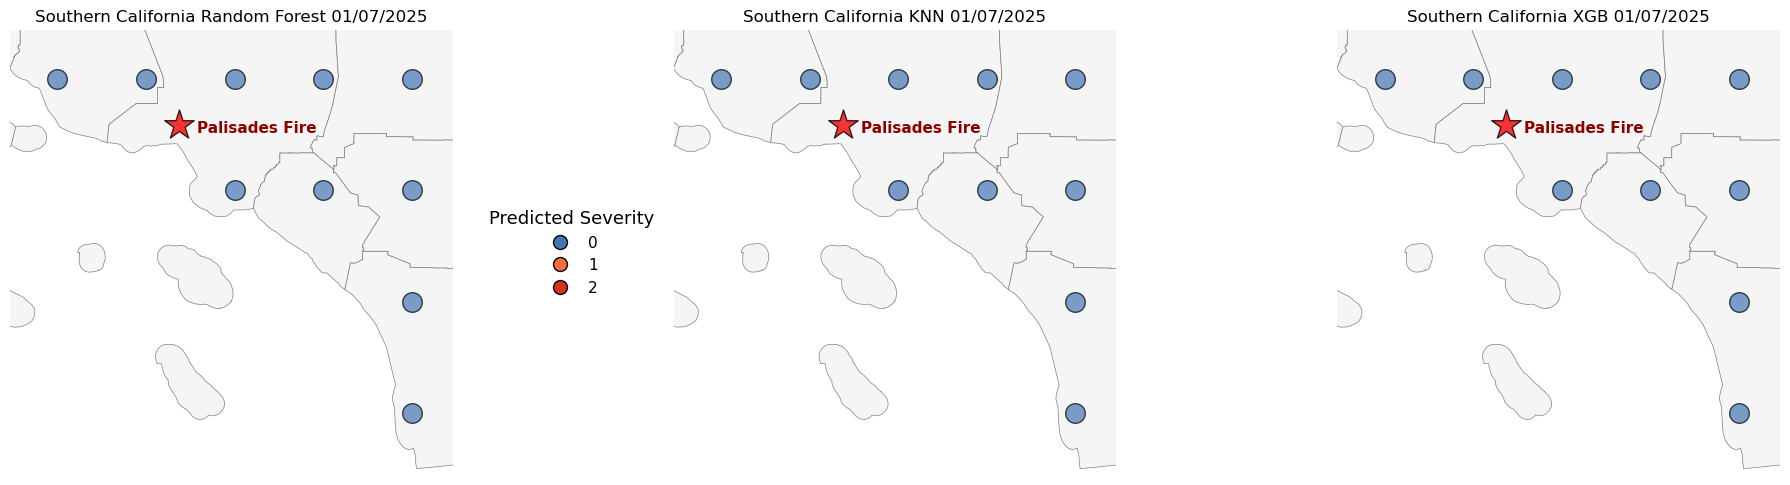

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_gdf, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_gdf, 'Prediction KNN', 'Palisades', ax=axes[1])
plot_map(pal_gdf, 'Prediction XGB', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California KNN 01/07/2025')
axes[2].set_title('Southern California XGB 01/07/2025')

plt.tight_layout()

plt.savefig("../plots/Palisades_predictions.png", dpi=300)